# Installing additional libraries

In [1]:
!pip -q install torchio monai
import os, sys
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.9/199.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00
Done


# Clonning MedNeXt repository

In [2]:
!git clone https://github.com/MIC-DKFZ/MedNeXt.git mednext
%cd mednext
!pip -q install -e .
%cd ..

sys.path.append('mednext')

Cloning into 'mednext'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (320/320), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 762 (delta 270), reused 244 (delta 244), pack-reused 442 (from 1)
Receiving objects: 100% (762/762), 522.43 KiB | 14.12 MiB/s, done.
Resolving deltas: 100% (459/459), done.
/kaggle/working/mednext
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.2 MB/s eta 0:00:00
/kaggle/working


In [3]:
import torch
import random
import torchio as tio
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.model_selection import train_test_split

from torchio.data import SubjectsLoader, SubjectsDataset
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from tqdm.notebook import tqdm
from pprint import pprint
import nibabel as nib

from monai.metrics import HausdorffDistanceMetric
from monai.metrics import DiceMetric
from monai.losses import DiceLoss

from nnunet_mednext import create_mednext_v1

import warnings
warnings.filterwarnings("ignore")
print("Done")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-02 09:13:57.850451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777713238.077231      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777713238.143440      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777713238.666397      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777713238.666437      23 computation_placer.cc:1

Done


# Data exploration and visualization

Total samples: 150


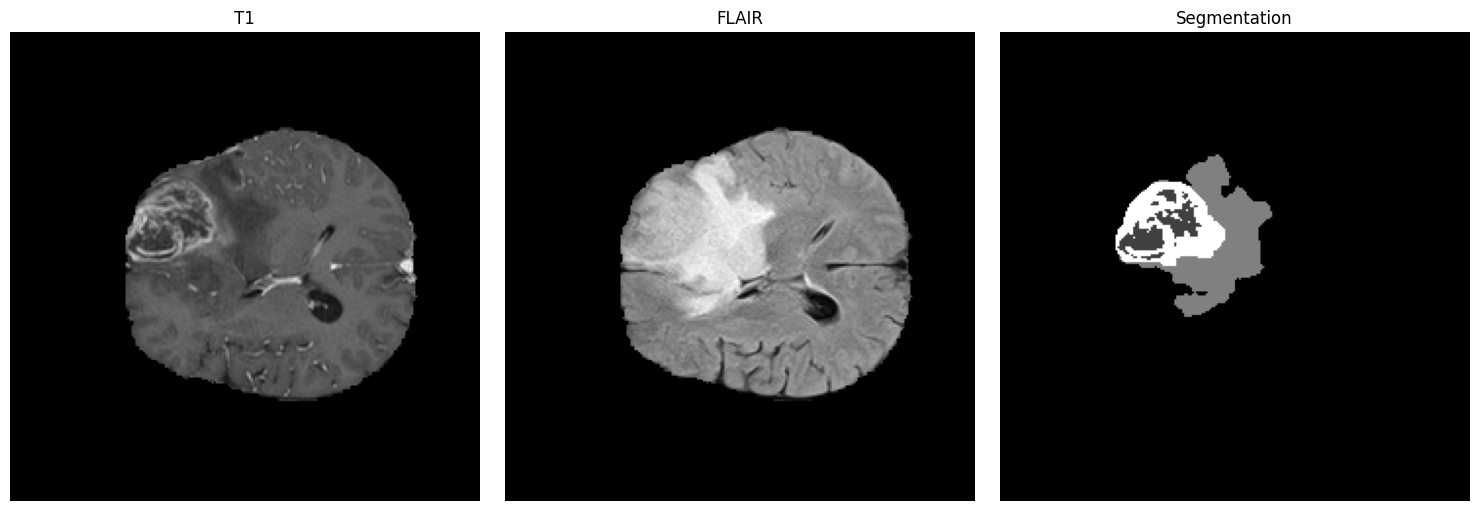

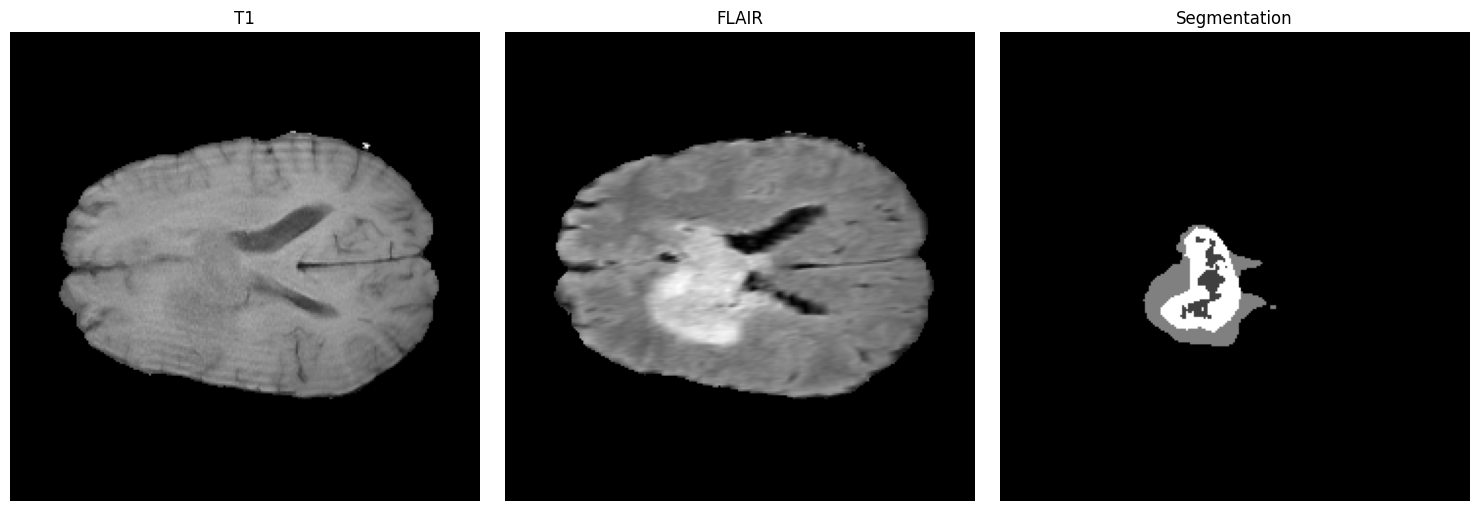

In [4]:
def collect_samples(root_dir, modalities=("t1", "flair")):
    samples = []

    patient_dirs = sorted(os.listdir(root_dir))

    for patient in patient_dirs:
        patient_path = os.path.join(root_dir, patient)

        if not os.path.isdir(patient_path):
            continue

        modality_paths = []

        for m in modalities:
            path = glob(f"{patient_path}/**/*{m}*.nii*", recursive=True)
            # to fix finding files in folders with file extensions
            if os.path.isdir(path[0]):
                path = os.path.join(path[0], os.listdir(path[0])[0])
                modality_paths.append(path)
                
            else: 
                modality_paths.append(path[0])

        seg = glob(f"{patient_path}/**/*seg*.nii*", recursive=True)
        if os.path.isdir(seg[0]):
            seg = os.path.join(seg[0], os.listdir(seg[0])[0])
        else:
            seg = seg[0]

        if len(modality_paths) < 2:
            print("Could not find both modalities for:", patient)
            continue
        
        if not modality_paths or not seg:
            continue
        # print(modality_paths)
        samples.append({
            "images": modality_paths,
            "label": seg
        })

    return samples

def plot_sample(sample):
    t1_path, flair_path = sample["images"]
    seg_path = sample["label"]

    t1 = nib.load(t1_path).get_fdata()
    flair = nib.load(flair_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()

    # choose middle slice (axial)
    z = t1.shape[-1] // 2

    t1_slice = t1[:, :, z]
    flair_slice = flair[:, :, z]
    seg_slice = seg[:, :, z]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(t1_slice, cmap="gray")
    axes[0].set_title("T1")
    axes[0].axis("off")

    axes[1].imshow(flair_slice, cmap="gray")
    axes[1].set_title("FLAIR")
    axes[1].axis("off")

    axes[2].imshow(seg_slice, cmap="gray")
    axes[2].set_title("Segmentation")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

root_dir = "/kaggle/input/datasets/spark2025/spark-brats150/spark_brats150"

samples = collect_samples(root_dir)

print(f"Total samples: {len(samples)}")

random_samples = random.sample(samples, 2)

for i in random_samples:
    plot_sample(i)

# Dataset Class

In [5]:
class BratsDataset(tio.SubjectsDataset):
    def __init__(self, samples, transform=None):
        subjects = []

        for sample in samples:
            image_paths = sample["images"]
            label_path = sample["label"]

            subject = tio.Subject(
                image=tio.ScalarImage(image_paths),
                label=tio.LabelMap(label_path)
            )

            subjects.append(subject)

        super().__init__(subjects, transform=transform)

# Data preprocessing

In [6]:
root_dir = "/kaggle/input/datasets/spark2025/spark-brats150/spark_brats150"

samples = collect_samples(root_dir)

train_samples, val_samples = train_test_split(samples, test_size=0.3, random_state=42, shuffle=True)

In [7]:
def clean_labels(subject):
    label = subject["label"].data
    label = label.long()
    label[label == 4] = 3
    subject["label"].set_data(label)
    return subject


preprocess = tio.Compose([
    clean_labels,
    tio.RescaleIntensity((0, 1)),
    tio.ZNormalization(),
    tio.Resample(1.0),
    tio.CropOrPad((128, 128, 64)),
])


train_transform = tio.Compose([
    preprocess,
    tio.RandomFlip(axes=(0, 1, 2), p=0.5),
    tio.RandomAffine(scales=(0.9, 1.1), degrees=10, translation=5, p=0.4),
    tio.RandomNoise(p=0.2),
    tio.RandomGamma(p=0.3),
])

train_dataset = BratsDataset(train_samples, transform=train_transform)
val_dataset = BratsDataset(val_samples, transform=preprocess)

train_loader = SubjectsLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)

val_loader = SubjectsLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)

In [8]:
for batch in train_loader:
    labels = batch["label"][tio.DATA]
    print(torch.unique(labels))
    break

tensor([0., 1., 2., 3.])


In [9]:
def visualize_batch(loader, num_samples=2):
    """
    Shows middle slices of image channels + mask
    """

    batch = next(iter(loader))

    images = batch["image"][tio.DATA]   # [B, C, H, W, D]
    labels = batch["label"][tio.DATA]   # [B, 1, H, W, D]

    B = images.shape[0]

    for b in range(min(B, num_samples)):

        img = images[b]   # [C,H,W,D]
        mask = labels[b, 0] # [H,W,D]

        depth = img.shape[-1]
        mid = depth // 2

        channels = img.shape[0]

        fig, axes = plt.subplots(1, channels + 1, figsize=(18, 6))

        for c in range(channels):
            axes[c].imshow(img[c, :, :, mid], cmap="gray")
            axes[c].set_title(f"Channel {c+1} Slice {mid}")
            axes[c].axis("off")

        axes[-1].imshow(mask[:, :, mid], cmap="jet")
        axes[-1].set_title("Mask")
        axes[-1].axis("off")

        plt.tight_layout()
        plt.show()

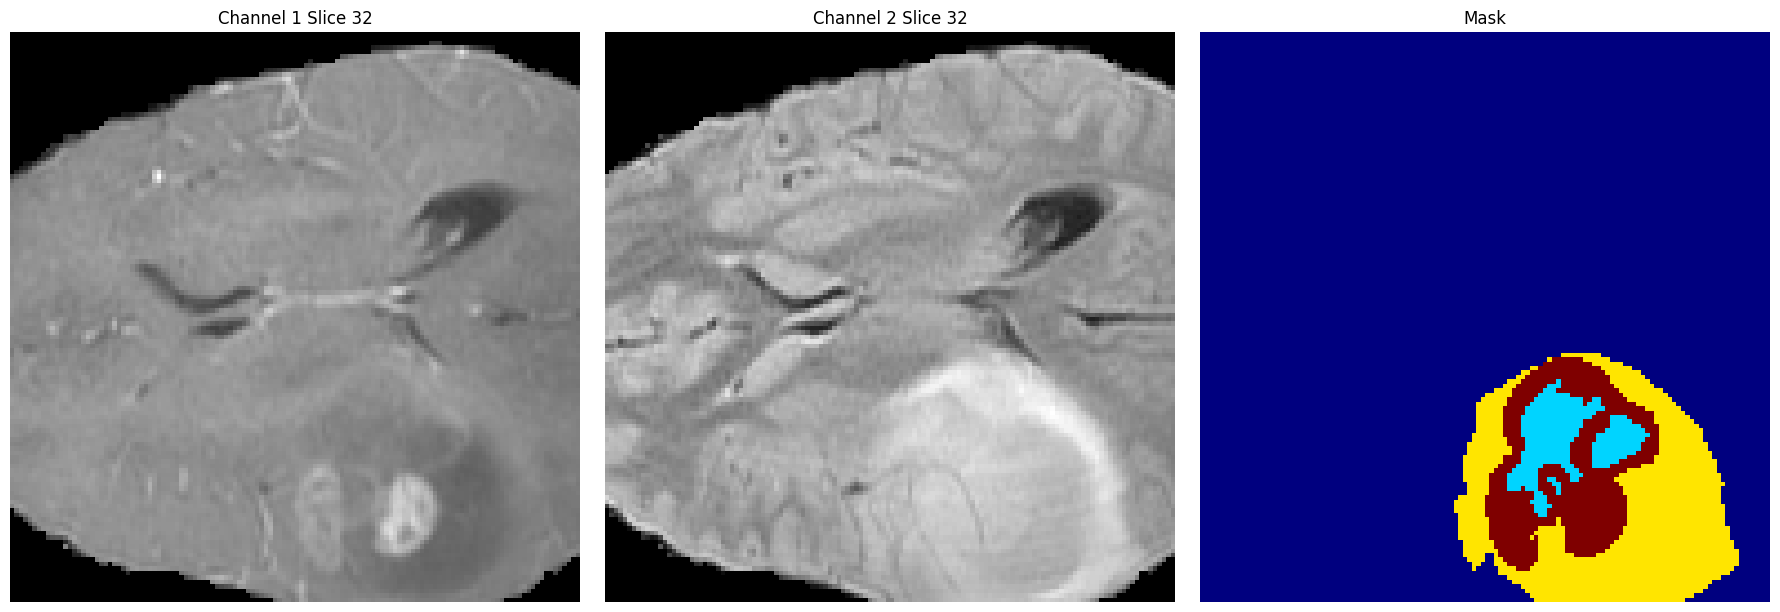

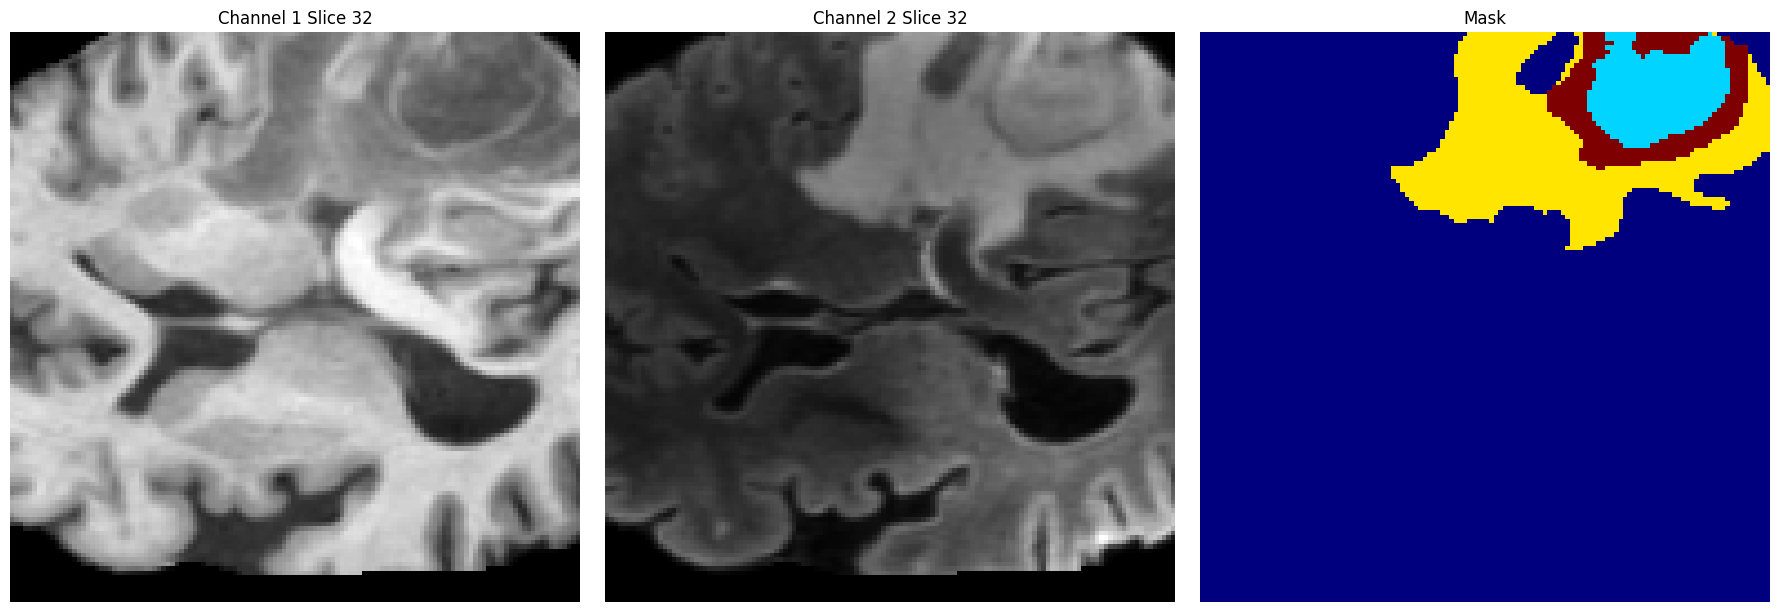

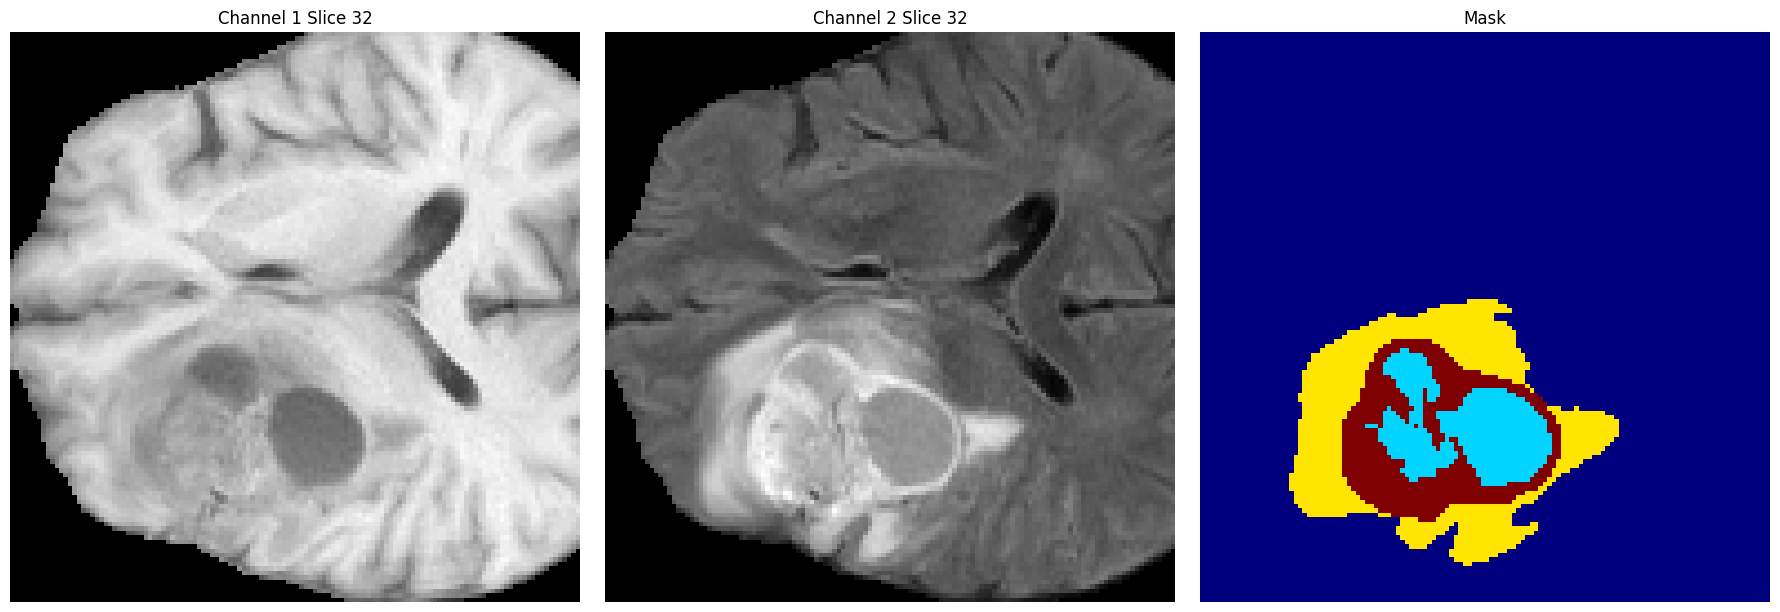

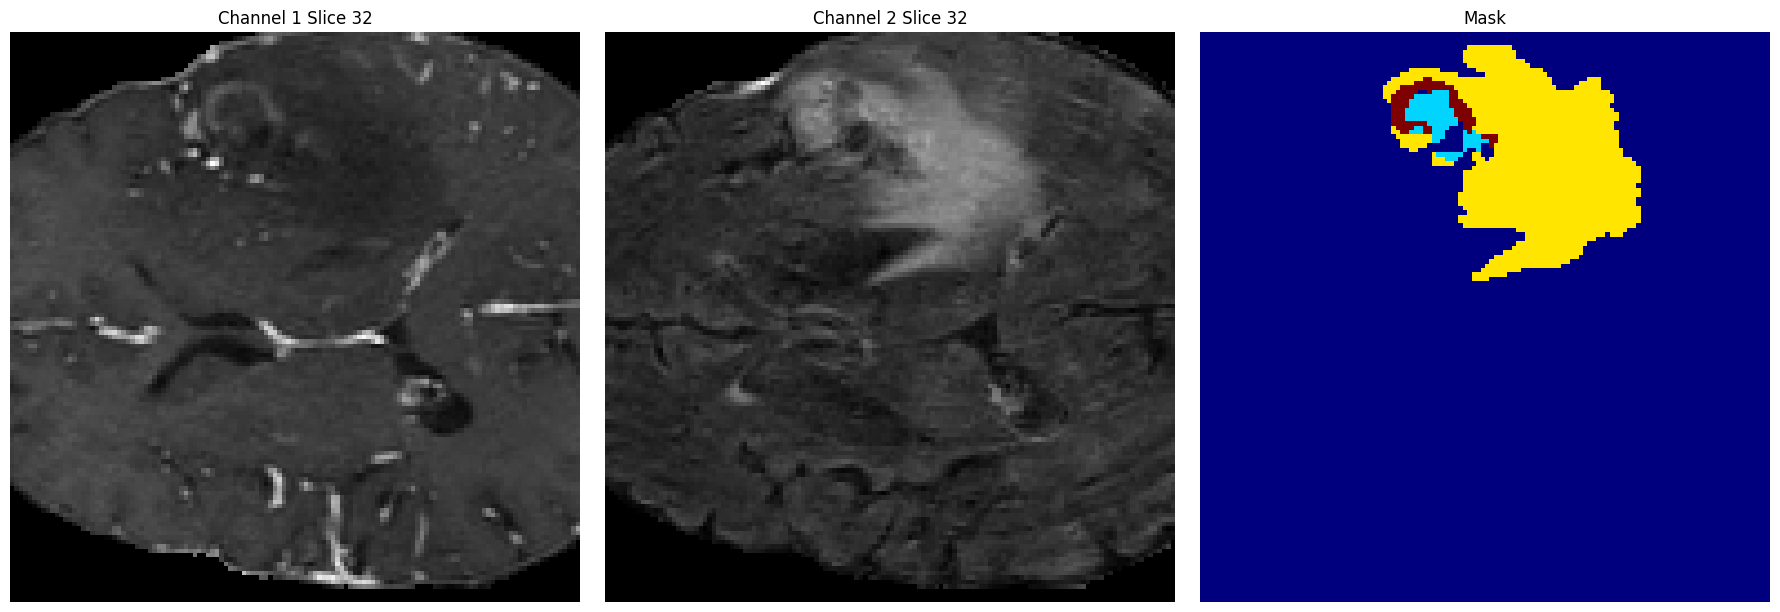

In [10]:
visualize_batch(train_loader, num_samples=2)
visualize_batch(val_loader, num_samples=2)

# Model Architecture

In [11]:
model = create_mednext_v1(
    num_input_channels=2,
    num_classes=4,
    model_id='S',
    kernel_size=3,
    deep_supervision=False
)

# # testing

x = torch.randn(1, 2, 128, 128, 64)

y = model(x)

print("Input :", x.shape)
print("Output:", y.shape)

Input : torch.Size([1, 2, 128, 128, 64])
Output: torch.Size([1, 4, 128, 128, 64])


# Model Training and Validation Loops

In [12]:
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

model.to(device)

scaler = torch.amp.GradScaler(enabled=device.type == "cuda")

num_epochs = 30
best_val_loss = float("inf")
epochs_no_improve = 0
patience = 5

train_losses = []
val_losses = []
dice_results = []

for epoch in range(num_epochs):

    # TRAIN 
    model.train()
    epoch_train_loss = 0.0

    train_loop = tqdm(train_loader, desc=f"Train {epoch+1}/{num_epochs}")

    for batch in train_loop:

        inputs = batch["image"][tio.DATA].to(device).float()
        labels = batch["label"][tio.DATA].to(device).long()   # (B,1,D,H,W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION 
    model.eval()
    epoch_val_loss = 0.0
    dice_metric.reset()

    val_loop = tqdm(val_loader, desc=f"Val {epoch+1}/{num_epochs}")

    with torch.no_grad():
        for batch in val_loop:

            inputs = batch["image"][tio.DATA].to(device).float()
            labels = batch["label"][tio.DATA].to(device).long()  # KEEP CHANNEL DIM

            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                outputs = model(inputs)
                val_loss = criterion(outputs, labels)

            epoch_val_loss += val_loss.item()

            # metrics
            preds = torch.argmax(outputs, dim=1)  # (B,D,H,W)
            targets = labels.squeeze(1)           # (B,D,H,W)

            preds = torch.nn.functional.one_hot(preds, num_classes=4)
            targets = torch.nn.functional.one_hot(targets, num_classes=4)

            preds = preds.permute(0, 4, 1, 2, 3).float().cpu()
            targets = targets.permute(0, 4, 1, 2, 3).float().cpu()

            dice_metric(preds, targets)

            val_loop.set_postfix(loss=val_loss.item())

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    dice_score = dice_metric.aggregate().mean().item()

    dice_results.append(dice_score)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f} | "
        f"Dice: {dice_score:.4f}"
    )

    scheduler.step()

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Train 1/30:   0%|          | 0/53 [00:00<?, ?it/s]

Val 1/30:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1/30 | Train: 0.6464 | Val: 0.5644 | Dice: 0.2580


Train 2/30:   0%|          | 0/53 [00:00<?, ?it/s]

Val 2/30:   0%|          | 0/23 [00:00<?, ?it/s]

...

Val 29/30:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 29/30 | Train: 0.2490 | Val: 0.3253 | Dice: 0.5822


Train 30/30:   0%|          | 0/53 [00:00<?, ?it/s]

Val 30/30:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 30/30 | Train: 0.2436 | Val: 0.3226 | Dice: 0.5849


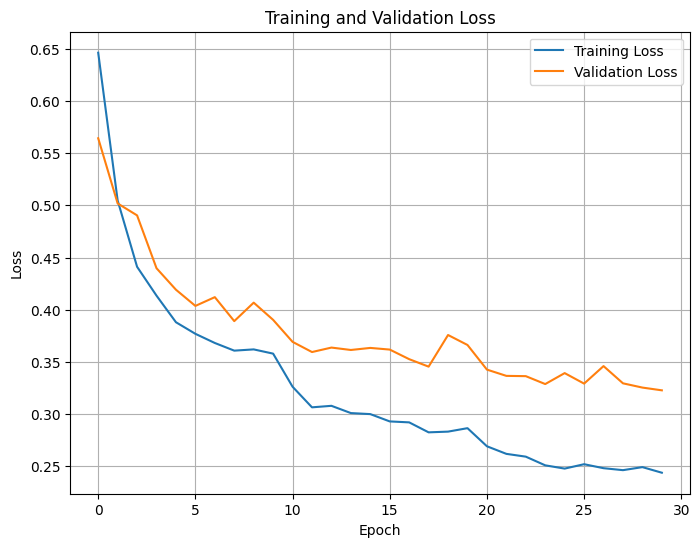

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

dice_metric = DiceMetric(include_background=False, reduction="mean_batch")

num_classes = 4
dice_scores = []
with torch.no_grad():
    val_loop = tqdm(val_loader, desc="Evaluating")
    
    for batch in val_loop:
        images = batch["image"]["data"].to(device).float()
        labels = batch["label"]["data"].to(device).long()

        if labels.shape[1] == 1:
            labels = labels.squeeze(1)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        preds_oh = torch.nn.functional.one_hot(preds, num_classes=num_classes)
        preds_oh = preds_oh.permute(0, 4, 1, 2, 3).float()

        labels_oh = torch.nn.functional.one_hot(labels, num_classes=num_classes)
        labels_oh = labels_oh.permute(0, 4, 1, 2, 3).float()

        dice_metric(y_pred=preds_oh, y=labels_oh)

    dice_scores = dice_metric.aggregate()
    dice_metric.reset()

et, tc, wt = dice_scores

print("Dice Scores:")
print(f"ET: {et.item():.4f}")
print(f"TC: {tc.item():.4f}")
print(f"WT: {wt.item():.4f}")
print(f"Mean Foreground: {dice_scores.mean().item():.4f}")

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Dice Scores:
ET: 0.5196
TC: 0.7051
WT: 0.5302
Mean Foreground: 0.5850


# Sample predictions

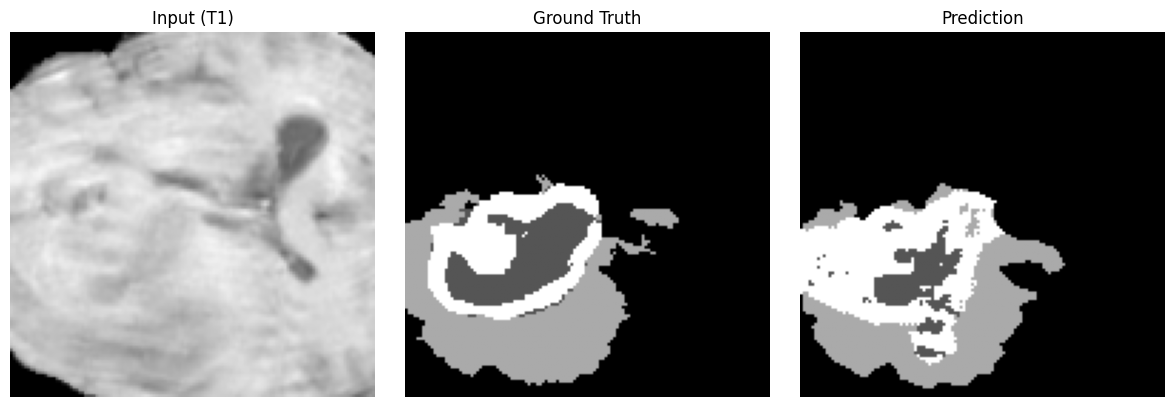

In [16]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

sample = next(iter(train_loader))

image = sample['image'][tio.DATA][0]  
label = sample['label'][tio.DATA][0]

input_tensor = image.unsqueeze(0).to(device).float()

with torch.no_grad():
    output = model(input_tensor)

    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1)   # (B, D, H, W)

pred = pred.cpu()[0]
image = image.cpu()
label = label.cpu().squeeze(0)

# choose middle slice along depth
slice_idx = image.shape[-1] // 2

input_slice = image[0, :, :, slice_idx]   # first modality (T1)
label_slice = label[:, :, slice_idx]
pred_slice = pred[:, :, slice_idx]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(input_slice, cmap='gray')
axes[0].set_title('Input (T1)')
axes[0].axis('off')

axes[1].imshow(label_slice, cmap='gray')
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(pred_slice, cmap='gray')
axes[2].set_title('Prediction')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
image.shape

torch.Size([2, 128, 128, 64])